In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import glob
from pathlib import Path

# Import EPSP calculation function
try:
    from plastyfire.ephysutils import get_epsp_vector
    print("✓ Successfully imported get_epsp_vector")
except ImportError:
    print("✗ Could not import get_epsp_vector - check plastyfire installation")

def compute_epsp_ratio_from_pkl(pkl_file, window=100):
    """Compute EPSP ratio from a single pkl file"""
    with open(pkl_file, 'rb') as f:
        data = pickle.load(f)
    
    t = data['t']
    v = data['v'] 
    spikes = data['pre_spikes']
    rho_GB = data['rho_GB']
    
    # Get initial and final rho states
    initial_rho = [0 if k[0] < 0.5 else 1 for k in rho_GB]
    final_rho = [0 if k[-1] < 0.5 else 1 for k in rho_GB]
    
    # Filter spikes within valid time window
    valid_spikes = spikes[spikes < (t[-1] - window)][:60]
    
    if len(valid_spikes) == 0:
        return None, None, initial_rho, final_rho
    
    # Compute EPSP values
    epsp_values = get_epsp_vector(t, v, valid_spikes, window)
    avg_epsp = np.mean(epsp_values) if len(epsp_values) > 0 else 0.0
    
    return epsp_values, avg_epsp, initial_rho, final_rho

def analyze_ephys_data_directory(ephys_dir, cell_pair="205559_199162"):
    """Analyze all pkl files in the ephys_data directory for a specific cell pair"""
    pattern = os.path.join(ephys_dir, f"ephys_data_{cell_pair}_*_trial_*.pkl")
    pkl_files = glob.glob(pattern)
    
    print(f"Found {len(pkl_files)} pkl files for cell pair {cell_pair}")
    
    results = []
    
    for pkl_file in sorted(pkl_files):
        try:
            # Extract rho config and trial from filename
            filename = os.path.basename(pkl_file)
            parts = filename.replace('.pkl', '').split('_')
            rho_config = '_'.join(parts[3:-2])  # Extract rho config part
            trial = int(parts[-1])
            
            # Compute EPSP
            epsp_values, avg_epsp, initial_rho, final_rho = compute_epsp_ratio_from_pkl(pkl_file)
            
            if avg_epsp is not None:
                results.append({
                    'filename': filename,
                    'rho_config': rho_config,
                    'trial': trial,
                    'avg_epsp': avg_epsp,
                    'initial_rho': str(initial_rho),
                    'final_rho': str(final_rho),
                    'n_spikes': len(epsp_values) if epsp_values is not None else 0
                })
                print(f"✓ {filename}: EPSP = {avg_epsp:.4f} mV")
            else:
                print(f"✗ {filename}: No valid spikes")
                
        except Exception as e:
            print(f"✗ Error processing {filename}: {e}")
    
    return pd.DataFrame(results)

# Set up paths
ephys_dir = "/home/dhuruva/projects/ctb-emuller/dhuruva/plastyfire/refitting_results/fitting/n1/seed19091997/ephys_data"
cell_pair = "205559_199162"

print(f"Analyzing ephys data in: {ephys_dir}")
print(f"Cell pair: {cell_pair}")
print("-" * 60)


/cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v3/MPI/gcc12/openmpi4/hdf5-mpi/1.14.2/lib/python3.11/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 1.14.4 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


✓ Successfully imported get_epsp_vector
Analyzing ephys data in: /home/dhuruva/projects/ctb-emuller/dhuruva/plastyfire/refitting_results/fitting/n1/seed19091997/ephys_data
Cell pair: 205559_199162
------------------------------------------------------------


In [2]:
# Run the analysis
results_df = analyze_ephys_data_directory(ephys_dir, cell_pair)

print("\n" + "="*60)
print("ANALYSIS RESULTS")
print("="*60)

if not results_df.empty:
    print(f"\nTotal files processed: {len(results_df)}")
    print(f"Unique rho configurations: {results_df['rho_config'].nunique()}")
    print(f"Trials per configuration: {results_df.groupby('rho_config')['trial'].count().iloc[0]}")
    
    # Summary statistics
    print(f"\nEPSP Statistics:")
    print(f"  Mean EPSP: {results_df['avg_epsp'].mean():.4f} mV")
    print(f"  Std EPSP: {results_df['avg_epsp'].std():.4f} mV")
    print(f"  Min EPSP: {results_df['avg_epsp'].min():.4f} mV")
    print(f"  Max EPSP: {results_df['avg_epsp'].max():.4f} mV")
    
    # Group by rho configuration
    print(f"\nResults by rho configuration:")
    for rho_config in sorted(results_df['rho_config'].unique()):
        config_data = results_df[results_df['rho_config'] == rho_config]
        print(f"  {rho_config}: {len(config_data)} trials, mean EPSP = {config_data['avg_epsp'].mean():.4f} ± {config_data['avg_epsp'].std():.4f} mV")
    
    # Display the dataframe
    print(f"\nDetailed Results:")
    display(results_df[['rho_config', 'trial', 'avg_epsp', 'n_spikes']].head(10))
    
else:
    print("No valid results found!")


Found 20 pkl files for cell pair 205559_199162
✓ ephys_data_205559_199162_1_1_0_1_0_0_1_1_trial_0.pkl: EPSP = 1.9817 mV
✓ ephys_data_205559_199162_1_1_0_1_0_0_1_1_trial_1.pkl: EPSP = 1.9131 mV
✓ ephys_data_205559_199162_1_1_0_1_0_0_1_1_trial_2.pkl: EPSP = 1.8044 mV
✓ ephys_data_205559_199162_1_1_0_1_0_0_1_1_trial_3.pkl: EPSP = 1.8088 mV
✓ ephys_data_205559_199162_1_1_0_1_0_0_1_1_trial_4.pkl: EPSP = 1.7955 mV
✓ ephys_data_205559_199162_1_1_0_1_0_0_1_1_trial_5.pkl: EPSP = 1.9821 mV
✓ ephys_data_205559_199162_1_1_0_1_0_0_1_1_trial_6.pkl: EPSP = 1.8681 mV
✓ ephys_data_205559_199162_1_1_0_1_0_0_1_1_trial_7.pkl: EPSP = 1.9579 mV
✓ ephys_data_205559_199162_1_1_0_1_0_0_1_1_trial_8.pkl: EPSP = 1.9821 mV
✓ ephys_data_205559_199162_1_1_0_1_0_0_1_1_trial_9.pkl: EPSP = 1.8845 mV
✓ ephys_data_205559_199162_1_1_0_1_1_0_1_1_trial_0.pkl: EPSP = 2.9229 mV
✓ ephys_data_205559_199162_1_1_0_1_1_0_1_1_trial_1.pkl: EPSP = 2.9345 mV
✓ ephys_data_205559_199162_1_1_0_1_1_0_1_1_trial_2.pkl: EPSP = 2.8378 mV
✓ ep

,rho_config,trial,avg_epsp,n_spikes
0,199162_1_1_0_1_0_0_1_1,0,1.981748,60
1,199162_1_1_0_1_0_0_1_1,1,1.913089,60
2,199162_1_1_0_1_0_0_1_1,2,1.804427,60
3,199162_1_1_0_1_0_0_1_1,3,1.808844,60
4,199162_1_1_0_1_0_0_1_1,4,1.795543,60
5,199162_1_1_0_1_0_0_1_1,5,1.982090,60
6,199162_1_1_0_1_0_0_1_1,6,1.868145,60
7,199162_1_1_0_1_0_0_1_1,7,1.957865,60
8,199162_1_1_0_1_0_0_1_1,8,1.982145,60
9,199162_1_1_0_1_0_0_1_1,9,1.884460,60


/tmp/ipykernel_2349578/1394721752.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(epsp_data, labels=rho_configs)


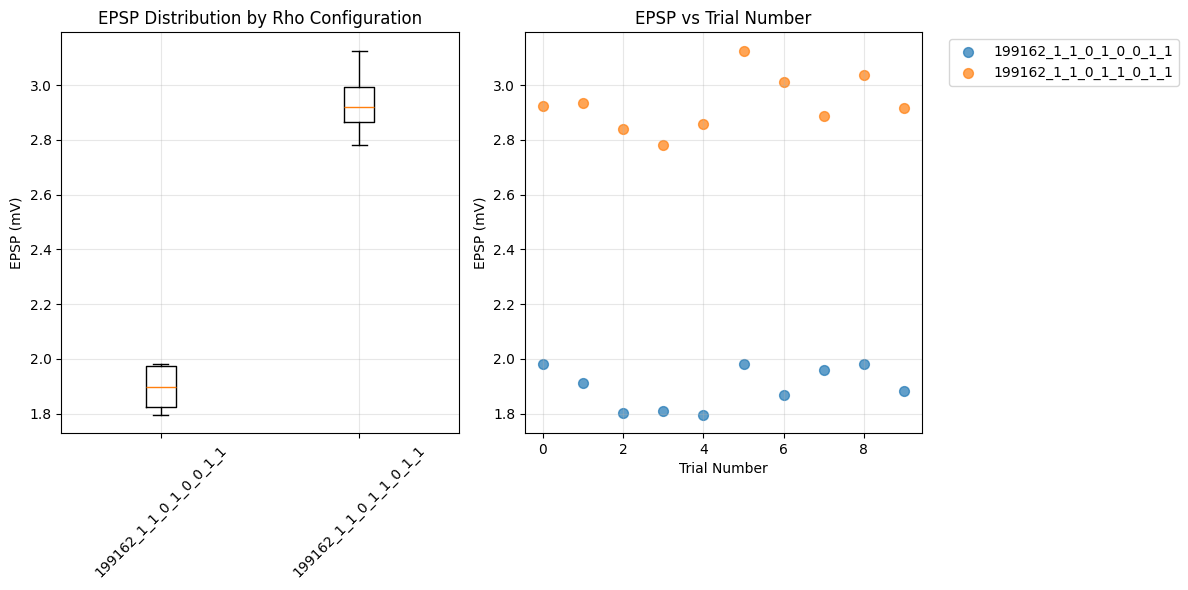


EPSP RATIO ANALYSIS

Configuration Summary:
                          mean     std  count
rho_config                                   
199162_1_1_0_1_0_0_1_1  1.8978  0.0769     10
199162_1_1_0_1_1_0_1_1  2.9311  0.1023     10

Ratio 199162_1_1_0_1_1_0_1_1 / 199162_1_1_0_1_0_0_1_1: 1.5445
T-test p-value: 0.0000


In [3]:
# Optional: Plotting and further analysis
import matplotlib.pyplot as plt

if not results_df.empty:
    # Plot EPSP values by rho configuration
    plt.figure(figsize=(12, 6))
    
    # Box plot of EPSP values by rho configuration
    plt.subplot(1, 2, 1)
    rho_configs = sorted(results_df['rho_config'].unique())
    epsp_data = [results_df[results_df['rho_config'] == config]['avg_epsp'].values for config in rho_configs]
    
    plt.boxplot(epsp_data, labels=rho_configs)
    plt.xticks(rotation=45)
    plt.ylabel('EPSP (mV)')
    plt.title('EPSP Distribution by Rho Configuration')
    plt.grid(True, alpha=0.3)
    
    # Scatter plot of trials
    plt.subplot(1, 2, 2)
    for i, config in enumerate(rho_configs):
        config_data = results_df[results_df['rho_config'] == config]
        plt.scatter(config_data['trial'], config_data['avg_epsp'], 
                   label=config, alpha=0.7, s=50)
    
    plt.xlabel('Trial Number')
    plt.ylabel('EPSP (mV)')
    plt.title('EPSP vs Trial Number')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Compute ratios between different rho configurations
    print("\n" + "="*60)
    print("EPSP RATIO ANALYSIS")
    print("="*60)
    
    # Find configurations with different rho states
    config_summary = results_df.groupby('rho_config')['avg_epsp'].agg(['mean', 'std', 'count']).round(4)
    print("\nConfiguration Summary:")
    print(config_summary)
    
    # Example: Compare first two configurations
    if len(rho_configs) >= 2:
        config1_data = results_df[results_df['rho_config'] == rho_configs[0]]['avg_epsp']
        config2_data = results_df[results_df['rho_config'] == rho_configs[1]]['avg_epsp']
        
        ratio = config2_data.mean() / config1_data.mean()
        print(f"\nRatio {rho_configs[1]} / {rho_configs[0]}: {ratio:.4f}")
        
        # Statistical test (optional)
        from scipy import stats
        t_stat, p_value = stats.ttest_ind(config1_data, config2_data)
        print(f"T-test p-value: {p_value:.4f}")

else:
    print("No data available for plotting")
